In [75]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
housing = fetch_california_housing()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

In [76]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [77]:
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


1. Exploratory Data Analysis


In [78]:
df.shape

(20640, 9)

In [79]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [80]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [81]:
df.nunique()

MedInc         12928
HouseAge          52
AveRooms       19392
AveBedrms      14233
Population      3888
AveOccup       18841
Latitude         862
Longitude        844
MedHouseVal     3842
dtype: int64

In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [84]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


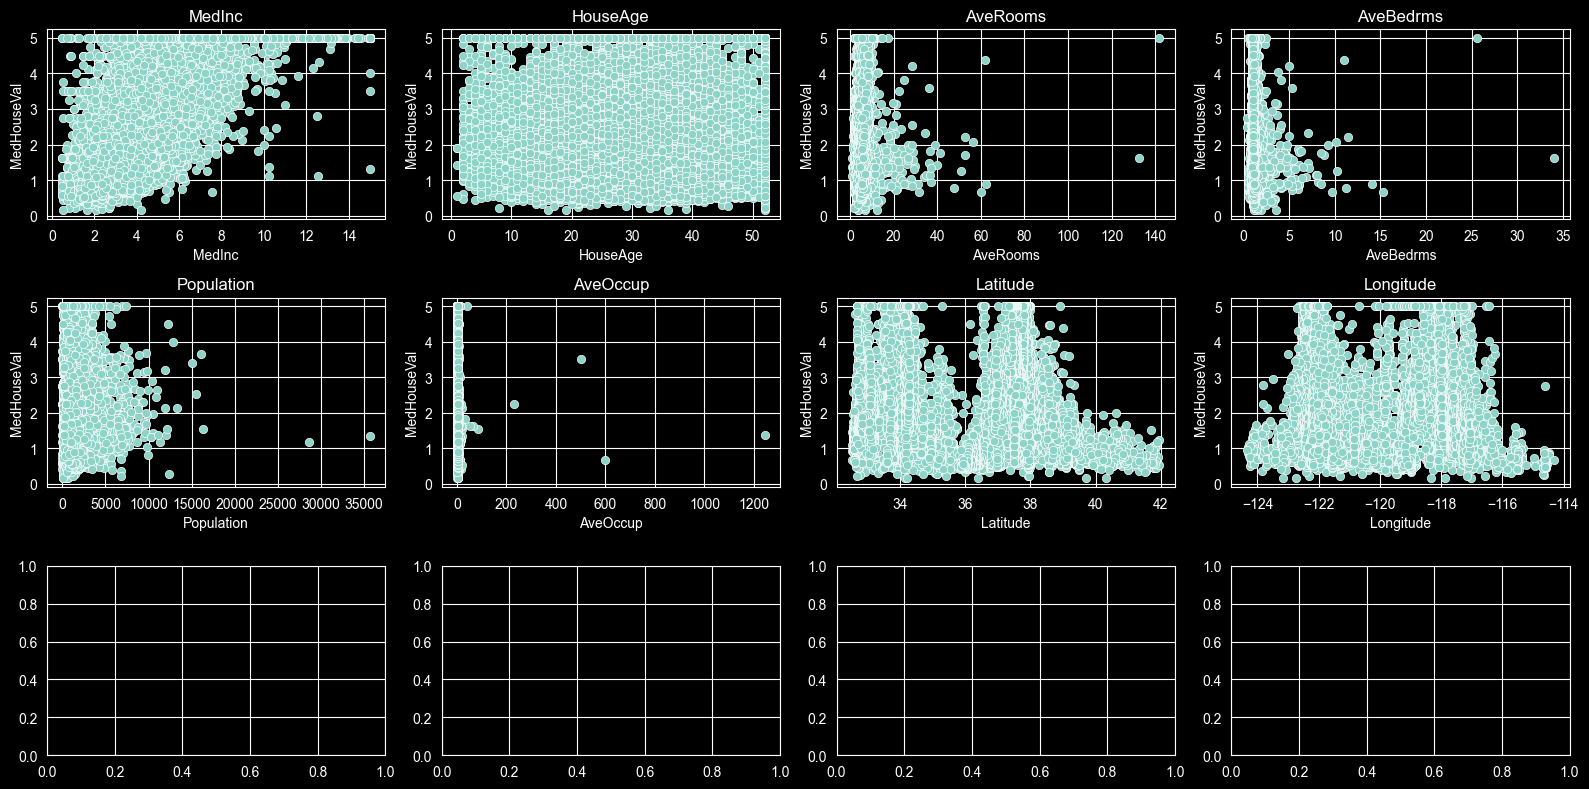

In [85]:
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(df.columns[:-1]):
    sns.scatterplot(x=df[feature], y=df['MedHouseVal'], ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()


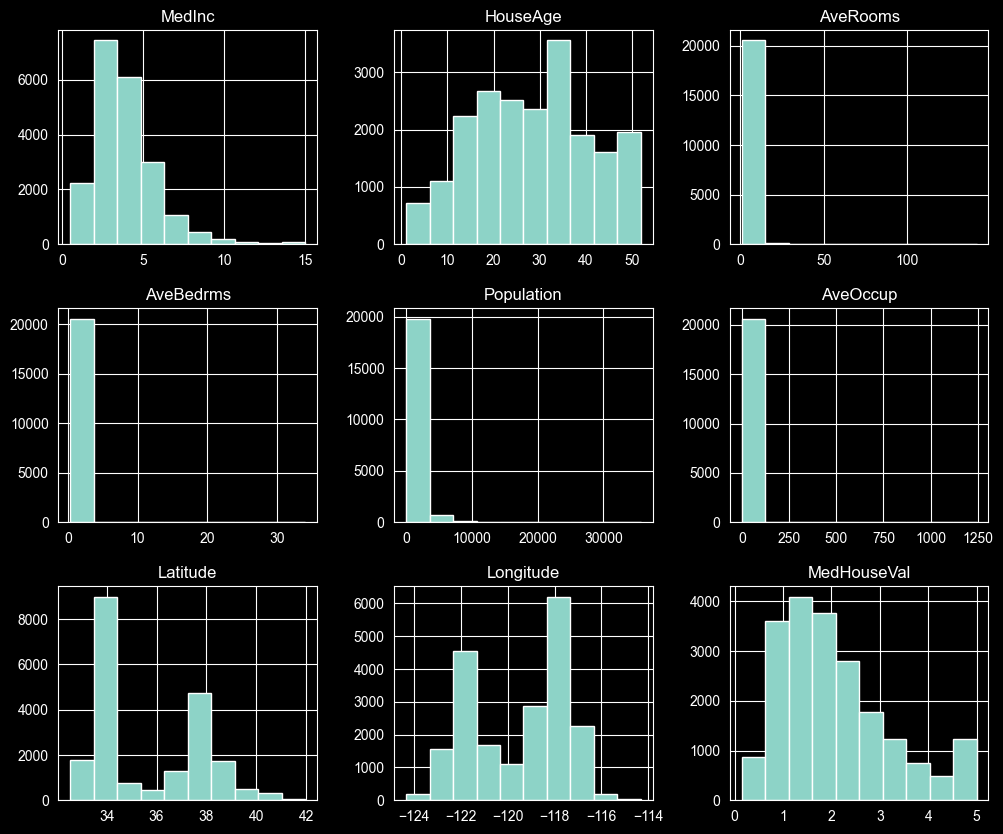

In [86]:
df.hist(figsize=(12, 10))
plt.show()

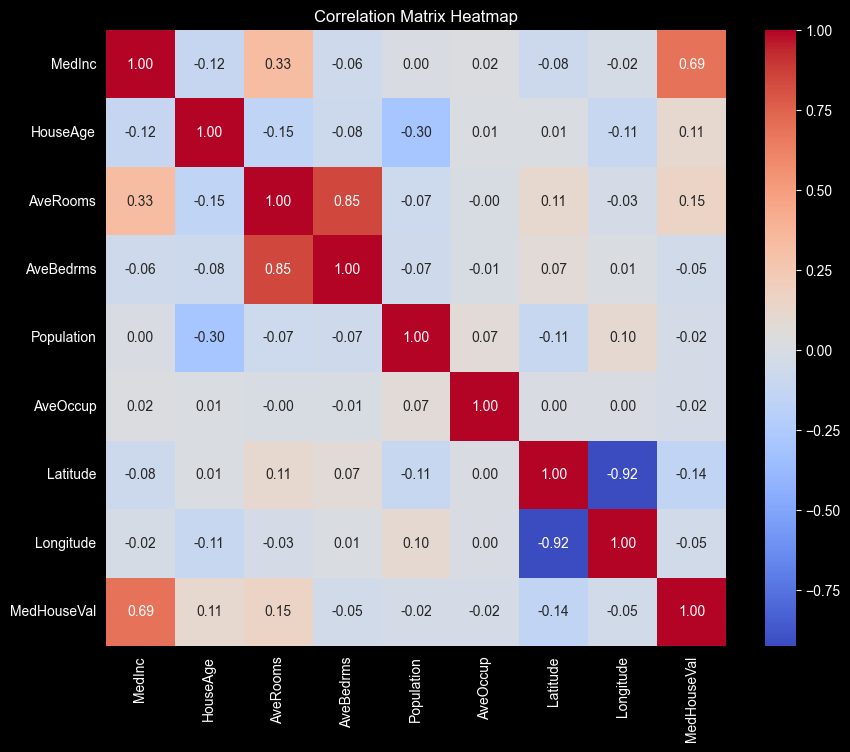

In [87]:
corr_mat = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

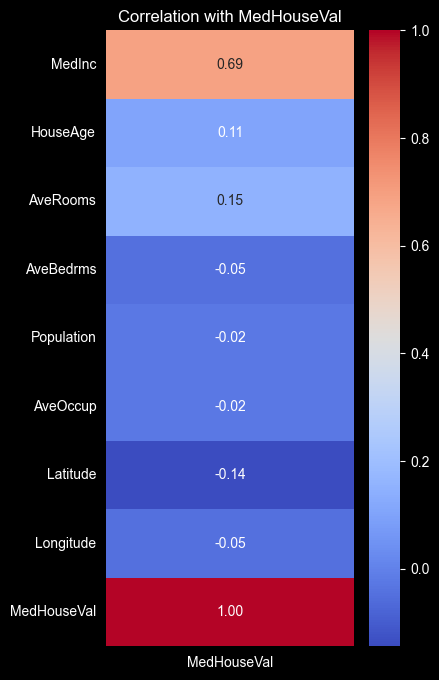

In [88]:
corr_target = df.corr()['MedHouseVal'].sort_values(ascending=False)
plt.figure(figsize=(4,8))
sns.heatmap(
    df.corr()[['MedHouseVal']],
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation with MedHouseVal")
plt.show()

2. Multiple Regression Model


In [89]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [90]:
x = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

In [91]:
X_train,X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=10)
print(X_train.shape, X_test.shape)


(16512, 8) (4128, 8)


In [92]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f"Test data r-squared: {lr.score(X_test, y_test)}")
print(f"Test data r-squared: {lr.score(X_train, y_train)}")
inter = lr.intercept_
print(f"Intercept: {inter}")

Test data r-squared: 0.6009790143129101
Test data r-squared: 0.607404930502105
Intercept: -37.48696576537289


In [93]:
df['MedHouseVal'].skew()

np.float64(0.9777632739098335)

In [94]:
df['MedHouseVal'].min

<bound method Series.min of 0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64>

In [95]:
y_log = np.log(df['MedHouseVal'])
y_log.tail()

20635   -0.247180
20636   -0.260067
20637   -0.080126
20638   -0.166055
20639   -0.112050
Name: MedHouseVal, dtype: float64

In [96]:
y_log.skew()

np.float64(-0.17317539032496643)

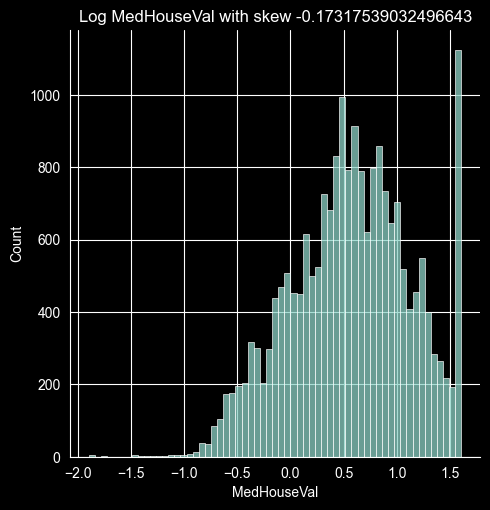

In [97]:
sns.displot(y_log)
plt.title(f"Log MedHouseVal with skew {y_log.skew()}")
plt.show()

In [98]:
x = df.drop(columns=['MedHouseVal'])
y = np.log(df['MedHouseVal'])
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)
print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


In [99]:
regr = LinearRegression()
regr.fit(X_train, y_train)
print(f"Test data r-squared: {regr.score(X_test, y_test)}")
print(f"Train data r-squared: {regr.score(X_train, y_train)}")
inter = regr.intercept_
print(f"Intercept: {inter}")
coef_df = pd.DataFrame(data=regr.coef_, index=X_train.columns, columns=['coefficients'])
coef_df.round(4)

Test data r-squared: 0.6037489256704882
Train data r-squared: 0.6168233836099825
Intercept: -24.57049046084645


,coefficients
MedInc,0.1861
HouseAge,0.0023
AveRooms,-0.0309
AveBedrms,0.2249
Population,0.0000
AveOccup,-0.0023
Latitude,-0.2891
Longitude,-0.2891


The VIF of MedInc just example (VIF  shuld be lower 5)

In [100]:
X_train_const = sm.add_constant(X_train)
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X_train_const.values, i) for i in range(X_train_const.shape[1])]
vif["feature"] = X_train_const.columns
print(vif)

            VIF     feature
0  17168.646399       const
1      2.474120      MedInc
2      1.240781    HouseAge
3      8.872377    AveRooms
4      7.538103   AveBedrms
5      1.135597  Population
6      1.008730    AveOccup
7      9.383400    Latitude
8      9.043759   Longitude


In [101]:
X_refined = x.drop(['AveRooms', 'AveBedrms', 'Longitude'], axis=1)

In [102]:
X_train_refined = X_train.drop(['AveRooms', 'AveBedrms', 'Longitude'], axis=1)
X_train_const = sm.add_constant(X_train_refined)
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X_train_const.values, i) for i in range(X_train_const.shape[1])]
vif["feature"] = X_train_const.columns
print(vif)

          VIF     feature
0  312.478326       const
1    1.022242      MedInc
2    1.112886    HouseAge
3    1.116454  Population
4    1.007027    AveOccup
5    1.019029    Latitude


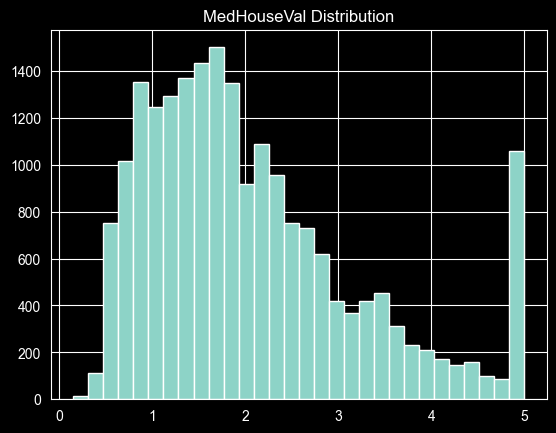

In [103]:

plt.hist(df['MedHouseVal'], bins=30)
plt.title('MedHouseVal Distribution')
plt.show()

In [109]:
X_refined = df[['MedInc', 'HouseAge', 'Population', 'Latitude']]  # or keep Longitude
X_train_r, X_test_r, y_train, y_test = train_test_split(X_refined, y_log, test_size=0.2, random_state=10)
lr_refined = LinearRegression().fit(X_train_r, y_train)
print("Refined model R²:", lr_refined.score(X_test_r, y_test))

Refined model R²: 0.4789636172531284


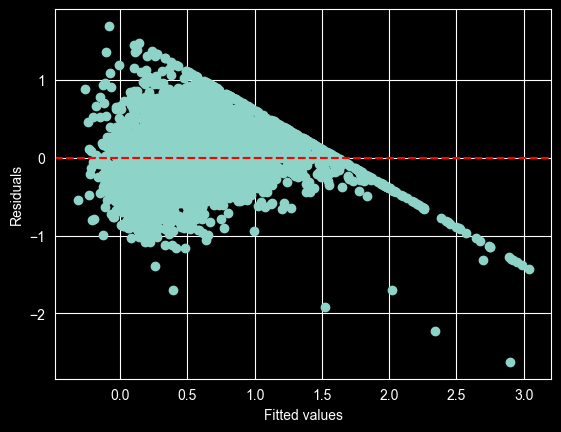

In [110]:
y_pred = lr_refined.predict(X_test_r)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()
